<a href="https://colab.research.google.com/github/SamuelRoblesArce/DefaultRate_Analysis_2020_2021/blob/main/DefaultRate_Analysis_2020_2021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1: Data Quality

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path ='/content/drive/MyDrive/Postulaciones/VoI/data_prueba.csv'

In [ ]:
# Leer CSV con pandas
df = pd.read_csv(file_path)

# Ver datos
df.head()

,NUM_ID,FECHA_CORTE,TIPO_ID,TIPO,VALOR_CREDITO,CREDITOS_ACTIVOS,CREDITOS_CANCELADOS,CREDITOS_ATRASOS,SAL_CTA_AHORROS,PLAZO_FIJO,...,TOTAL_EGRESOS,FECHA_1RA_OPERACION,NUM_OPERACIONES,FECHA_ULTI_DENEG,GARANTIA,DEFAULT,NUM_TARJETAS_M0,CUPO_TC_M0,SALDO_TOTAL_TC_M0,TIENE_TC
0,1,2020-11-01,C,MICROCREDITO ACUMULACIÓN SIMPLE,4000.0,1,1,0,396.61,0,...,445.50,2018-09-17,1,NaN,NINGUNA,4,0,0.0,0.00,1
1,2,2020-11-01,C,CONSUMO,6000.0,1,0,0,1147.36,0,...,858.00,2020-11-18,1,NaN,NINGUNA,4,2,5500.0,533.36,1
2,3,2020-10-01,CED,CONSUMO PRIORITARIO,3000.0,1,0,0,1021.82,1,...,1988.24,2020-10-23,1,NaN,NINGUNA,0,0,0.0,0.00,0
3,4,2020-12-01,C,MICROCREDITO ACUMULACIÓN SIMPLE,4000.0,1,4,0,2425.07,0,...,935.00,2020-12-02,1,NaN,NINGUNA,0,1,1120.0,0.00,1
4,5,2020-10-01,CED,MICROCREDITO,3000.0,1,0,0,27.01,0,...,1044.00,2020-10-28,1,NaN,NINGUNA,0,1,1500.0,549.99,1


In [ ]:
df.columns

Index(['NUM_ID', 'FECHA_CORTE', 'TIPO_ID', 'TIPO', 'VALOR_CREDITO',
       'CREDITOS_ACTIVOS', 'CREDITOS_CANCELADOS', 'CREDITOS_ATRASOS',
       'SAL_CTA_AHORROS', 'PLAZO_FIJO', 'PLAZO_FIJO_MONTO',
       'ACTIVIDAD_ECONOMICA', 'PROVINCIA_ACTIVIDAD', 'CANTON_ACTIVIDAD',
       'FECHA_NACIMIENTO', 'SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACION',
       'NUMERO_CARGAS', 'TIPO_VIVIENDA', 'ANTIGUEDAD_RESIDENCIA',
       'MARCA_CELULAR', 'TOTAL_ACTIVO', 'TOTAL_PASIVOS',
       'TOTAL_PATRIMONIO_NETO', 'TOTAL_INGRESOS', 'TOTAL_EGRESOS',
       'FECHA_1RA_OPERACION', 'NUM_OPERACIONES', 'FECHA_ULTI_DENEG',
       'GARANTIA', 'DEFAULT', 'NUM_TARJETAS_M0', 'CUPO_TC_M0',
       'SALDO_TOTAL_TC_M0', 'TIENE_TC'],
      dtype='object')

In [ ]:
df.dtypes

,0
NUM_ID,int64
FECHA_CORTE,object
TIPO_ID,object
TIPO,object
VALOR_CREDITO,float64
CREDITOS_ACTIVOS,int64
CREDITOS_CANCELADOS,int64
CREDITOS_ATRASOS,int64
SAL_CTA_AHORROS,float64
PLAZO_FIJO,int64


## Nulos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24292 entries, 0 to 24291
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NUM_ID                 24292 non-null  int64  
 1   FECHA_CORTE            24292 non-null  object 
 2   TIPO_ID                24292 non-null  object 
 3   TIPO                   24292 non-null  object 
 4   VALOR_CREDITO          24292 non-null  float64
 5   CREDITOS_ACTIVOS       24292 non-null  int64  
 6   CREDITOS_CANCELADOS    24292 non-null  int64  
 7   CREDITOS_ATRASOS       24292 non-null  int64  
 8   SAL_CTA_AHORROS        24292 non-null  float64
 9   PLAZO_FIJO             24292 non-null  int64  
 10  PLAZO_FIJO_MONTO       24292 non-null  float64
 11  ACTIVIDAD_ECONOMICA    24288 non-null  object 
 12  PROVINCIA_ACTIVIDAD    24110 non-null  object 
 13  CANTON_ACTIVIDAD       24111 non-null  object 
 14  FECHA_NACIMIENTO       24289 non-null  object 
 15  SE

ANTIGUEDAD_RESIDENCIA  y FECHA_ULTI_DENEG son los que más nulos tienen

In [ ]:
# Conteo de nulos por columna
df.isnull().sum()

# % de nulos
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
FECHA_ULTI_DENEG,94.352050
ANTIGUEDAD_RESIDENCIA,64.980240
NUMERO_CARGAS,1.156759
PROVINCIA_ACTIVIDAD,0.749218
CANTON_ACTIVIDAD,0.745101
TIPO_VIVIENDA,0.049399
ACTIVIDAD_ECONOMICA,0.016466
FECHA_NACIMIENTO,0.012350
NIVEL_EDUCACION,0.004117
TIPO_ID,0.000000


### FECHA_ULTI_DENEG

In [ ]:
# Reviso las columnas con mayor cantidad de nulos para decidir que hacer con ellas

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df['FECHA_ULTI_DENEG'] = pd.to_datetime(df['FECHA_ULTI_DENEG'], errors='coerce')

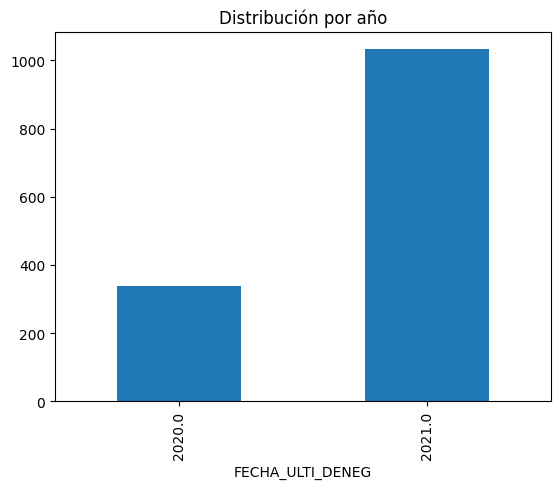

In [ ]:
df['FECHA_ULTI_DENEG'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por año')
plt.show()

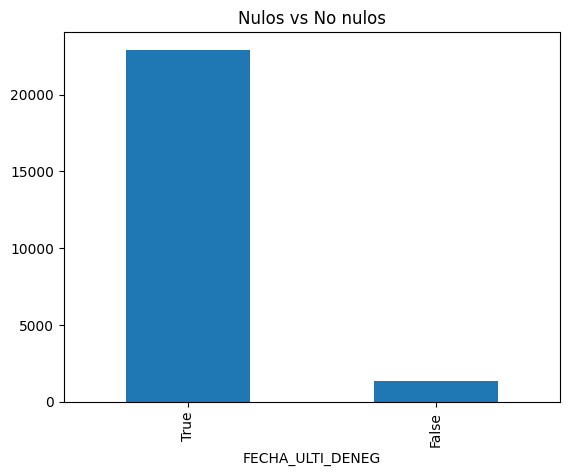

In [ ]:
df['FECHA_ULTI_DENEG'].isnull().value_counts().plot(kind='bar')
plt.title('Nulos vs No nulos')
plt.show()

Esta columna al tener muchos nulos no la voy a poder usar.

In [ ]:
df_clean = df.copy()

df_clean = df_clean.drop(columns=['FECHA_ULTI_DENEG'])

### ANTIGUEDAD_RESIDENCIA

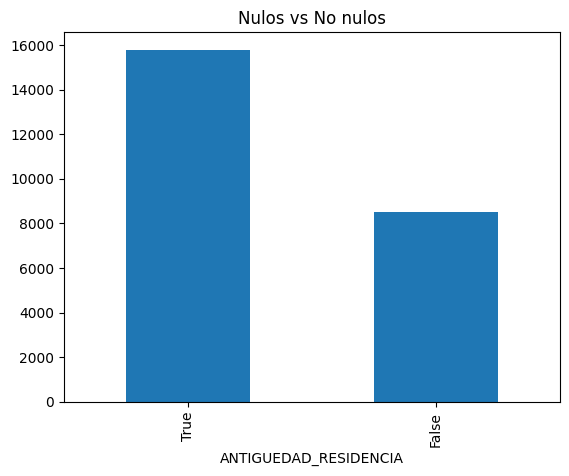

In [ ]:
df['ANTIGUEDAD_RESIDENCIA'].isnull().value_counts().plot(kind='bar')
plt.title('Nulos vs No nulos')
plt.show()

Vemos que una tercera parte de los datos son nulos.

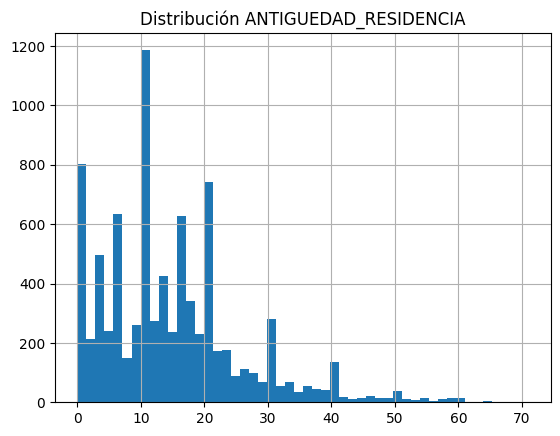

In [ ]:
df['ANTIGUEDAD_RESIDENCIA'].hist(bins=50)
plt.title('Distribución ANTIGUEDAD_RESIDENCIA')
plt.show()

In [ ]:
# podemos ver que los datos no son normales
df['ANTIGUEDAD_RESIDENCIA'].skew()

np.float64(1.1552944864891497)

Como no son normales vamos a imputar con la mediana

In [ ]:
# 1. Crear flag ANTES de imputar
df_clean['ANTIGUEDAD_RESIDENCIA_NULL'] = df_clean['ANTIGUEDAD_RESIDENCIA'].isnull().astype(int)

In [ ]:
# Calcular mediana
mediana = df_clean['ANTIGUEDAD_RESIDENCIA'].median()

# Imputar nulos
df_clean['ANTIGUEDAD_RESIDENCIA'] = df_clean['ANTIGUEDAD_RESIDENCIA'].fillna(mediana)

In [ ]:
df_clean[['ANTIGUEDAD_RESIDENCIA', 'ANTIGUEDAD_RESIDENCIA_NULL']].head()

,ANTIGUEDAD_RESIDENCIA,ANTIGUEDAD_RESIDENCIA_NULL
0,19.0,0
1,13.0,1
2,13.0,1
3,36.0,0
4,13.0,1


Aquí hemos reemplzado los nulos con la mediana. Pero como son la 3ra parte de los datos hemos creado una columna adicional (flag) que nos ayude a detectar cuales eran los nulos originales para poder conservar la mayor cantidad de información posible.

### Otros nulos

In [ ]:
cols_con_nulos = df_clean.columns[df_clean.isnull().sum() > 0]
cols_con_nulos

Index(['ACTIVIDAD_ECONOMICA', 'PROVINCIA_ACTIVIDAD', 'CANTON_ACTIVIDAD',
       'FECHA_NACIMIENTO', 'NIVEL_EDUCACION', 'NUMERO_CARGAS',
       'TIPO_VIVIENDA'],
      dtype='object')

In [ ]:
# Filtrar solo columnas numéricas con nulos
cols_num = df_clean[cols_con_nulos].select_dtypes(include=['int64', 'float64']).columns

In [ ]:
cols_num

Index(['NUMERO_CARGAS'], dtype='object')

Aplicamos skew a las columnas numericas, en este caso solo hay 1 "NUMERO_CARGAS", para ver si es normal o no, y decidir si imputarla con la media o la mediana.

In [ ]:
df_clean[cols_num].skew()

,0
NUMERO_CARGAS,1.0354


In [ ]:
# Calcular mediana
mediana = df_clean['NUMERO_CARGAS'].median()

# Imputar nulos
df_clean['NUMERO_CARGAS'] = df_clean['NUMERO_CARGAS'].fillna(mediana)

Ahora vamos a reemplazar las demás variables categorias con la moda.

In [ ]:
cols_con_nulos = df_clean.columns[df_clean.isnull().sum() > 0]

In [ ]:
cols_con_nulos

Index(['ACTIVIDAD_ECONOMICA', 'PROVINCIA_ACTIVIDAD', 'CANTON_ACTIVIDAD',
       'FECHA_NACIMIENTO', 'NIVEL_EDUCACION', 'TIPO_VIVIENDA'],
      dtype='object')

In [ ]:
#aquí compruebo que en mi data set limpio ya solo quedan las 6 columnas categoricas con nulos

In [ ]:
for col in cols_con_nulos:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

In [ ]:
cols_con_nulos = df_clean.columns[df_clean.isnull().sum() > 0]
cols_con_nulos

Index([], dtype='object')

Listo ya no tenemos nulos.

## Validez de Variables

### Estado_Civil

In [ ]:
df_clean['ESTADO_CIVIL'].value_counts(dropna=False)

,count
ESTADO_CIVIL,
CASADO/A,9789
SOLTERO/A,5018
CASADO,4117
SOLTERO,2250
DIVORCIADO/A,1236
DIVORCIADO,523
VIUDO/A,516
UNIONLIBRE,437
VIUDO,231


In [ ]:
mapeo_estado = {
    'CASADO': 'CASADO',
    'CASADO/A': 'CASADO',

    'SOLTERO': 'SOLTERO',
    'SOLTERO/A': 'SOLTERO',

    'DIVORCIADO': 'DIVORCIADO',
    'DIVORCIADO/A': 'DIVORCIADO',

    'VIUDO': 'VIUDO',
    'VIUDO/A': 'VIUDO',

    'UNIONLIBRE': 'UNION_LIBRE',
    'UNION LIBRE': 'UNION_LIBRE'
}

df_clean['ESTADO_CIVIL'] = df_clean['ESTADO_CIVIL'].replace(mapeo_estado)

In [ ]:
df_clean['ESTADO_CIVIL'].value_counts(dropna=False)

,count
ESTADO_CIVIL,
CASADO,13906
SOLTERO,7268
DIVORCIADO,1759
VIUDO,747
UNION_LIBRE,612


### TIPO_VIVIENDA

In [ ]:
df_clean['TIPO_VIVIENDA'].value_counts(dropna=False)

,count
TIPO_VIVIENDA,
PROPIA NO HIPOTECADA,9624
VIVE CON FAMILIARES,5707
P,4028
F,2519
ARRENDADA,1551
A,734
PROPIA HIPOTECADA,123
H,4
PRESTADA,2


In [ ]:
mapeo_vivienda = {
    # Propia
    'PROPIA NO HIPOTECADA': 'PROPIA',
    'P': 'PROPIA',

    # Familiar
    'VIVE CON FAMILIARES': 'FAMILIAR',
    'F': 'FAMILIAR',

    # Alquiler
    'ARRENDADA': 'ALQUILADA',
    'A': 'ALQUILADA',

    # Hipotecada
    'PROPIA HIPOTECADA': 'HIPOTECADA',
    'H': 'HIPOTECADA',
    'PRESTADA': 'HIPOTECADA'  # o podrías usar 'OTRO'
}

df_clean['TIPO_VIVIENDA'] = df_clean['TIPO_VIVIENDA'].replace(mapeo_vivienda)

In [ ]:
df_clean['TIPO_VIVIENDA'].value_counts(dropna=False)

,count
TIPO_VIVIENDA,
PROPIA,13652
FAMILIAR,8226
ALQUILADA,2285
HIPOTECADA,129


## Duplicados

### Crear codmes

In [ ]:
df_clean['FECHA_CORTE'] = pd.to_datetime(df_clean['FECHA_CORTE'])

df_clean['CODMES'] = df_clean['FECHA_CORTE'].dt.strftime('%Y%m')

In [ ]:
df_clean[['NUM_ID', 'FECHA_CORTE', 'CODMES']].head(10)

,NUM_ID,FECHA_CORTE,CODMES
0,1,2020-11-01,202011
1,2,2020-11-01,202011
2,3,2020-10-01,202010
3,4,2020-12-01,202012
4,5,2020-10-01,202010
5,6,2020-11-01,202011
6,7,2020-08-01,202008
7,8,2020-11-01,202011
8,9,2020-11-01,202011
9,10,2021-07-01,202107


In [ ]:
duplicados = df_clean[df_clean.duplicated(subset=['NUM_ID', 'CODMES'], keep=False)]

duplicados.shape

(0, 37)

In [ ]:
duplicados = df_clean[df_clean.duplicated(subset=['NUM_ID'], keep=False)]

duplicados.shape

(0, 37)

No hay duplicados, como vemos el num_id de por si es único.

## Outliers

In [ ]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
# Variables numéricas
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Excluir binarias
cols_outliers = [col for col in num_cols if df_clean[col].nunique() > 15 and col != 'NUM_ID']

In [ ]:
cols_disc = [col for col in num_cols if df_clean[col].nunique() <= 15]
cols_disc

['CREDITOS_ACTIVOS',
 'CREDITOS_ATRASOS',
 'PLAZO_FIJO',
 'NUMERO_CARGAS',
 'NUM_OPERACIONES',
 'DEFAULT',
 'NUM_TARJETAS_M0',
 'TIENE_TC',
 'ANTIGUEDAD_RESIDENCIA_NULL']

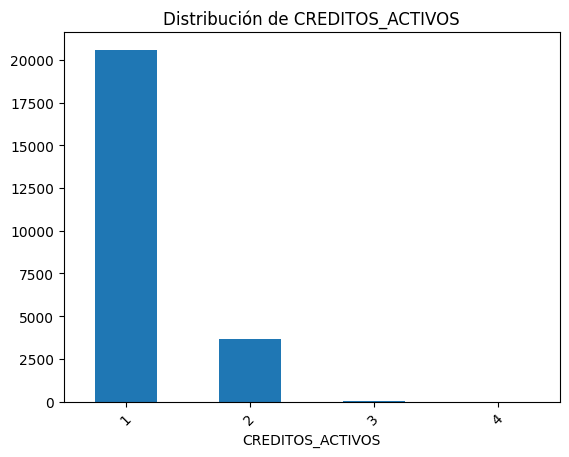

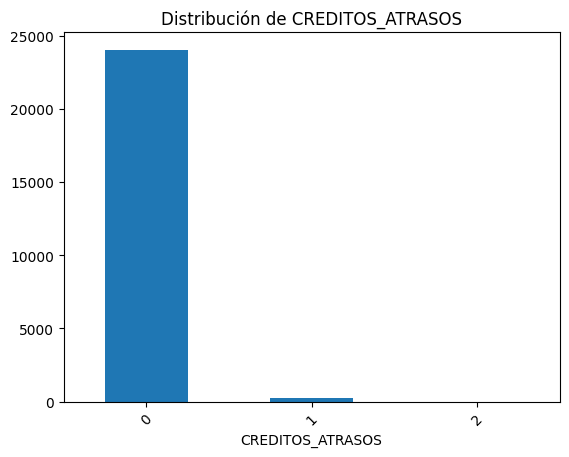

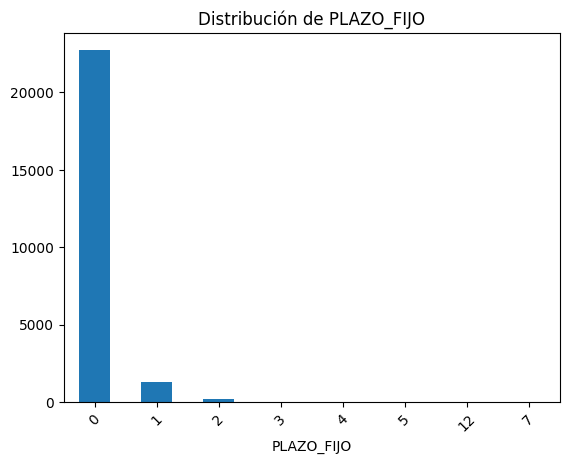

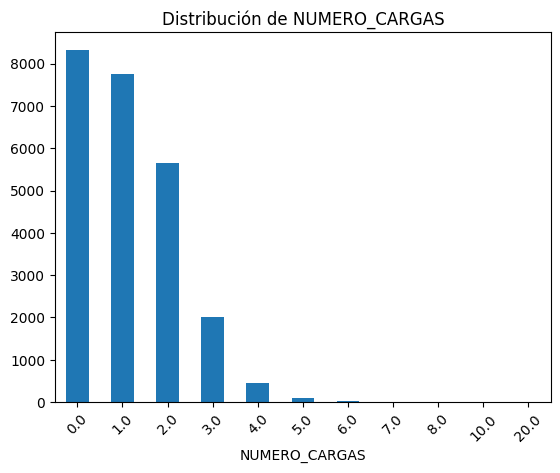

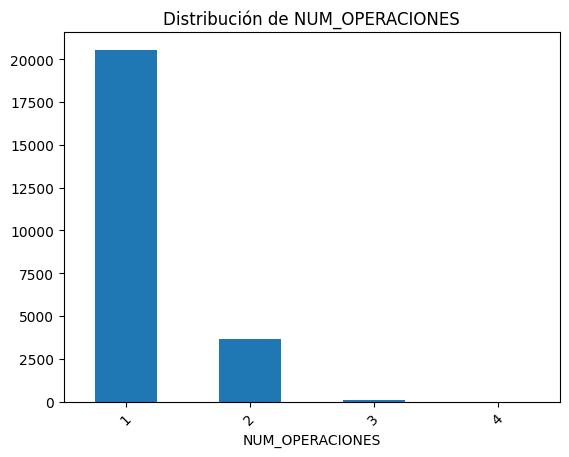

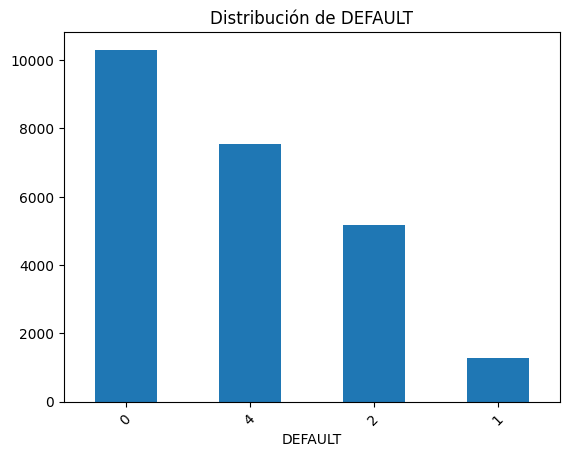

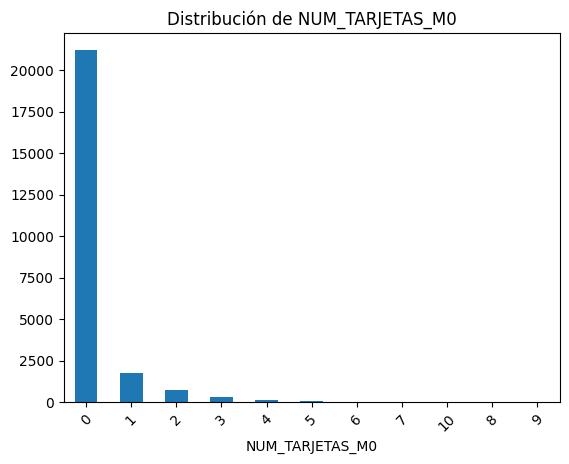

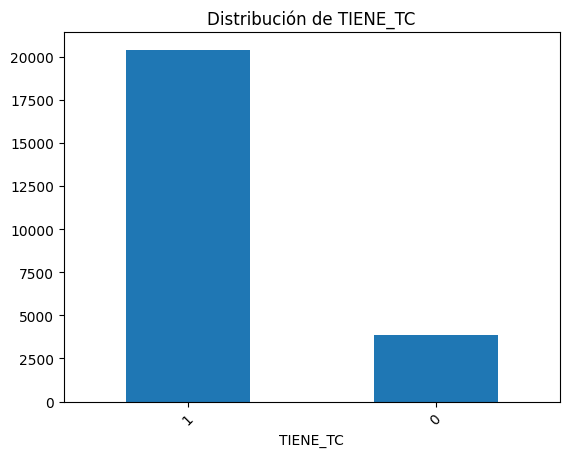

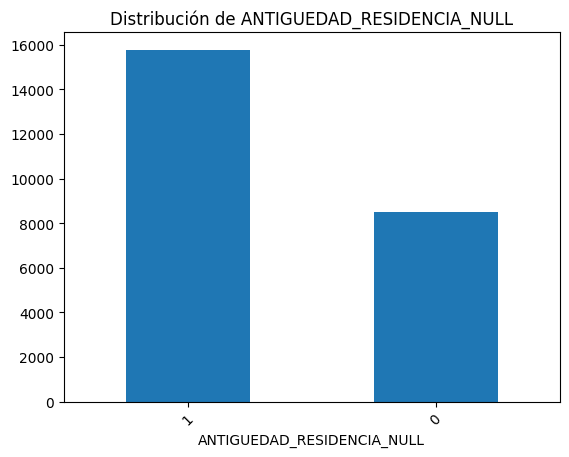

In [ ]:
for col in cols_disc:
    df_clean[col].value_counts().plot(kind='bar')
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
#Aquí hay algunas variables que las podríamos agrupar si las consideramos categoricas

In [ ]:
cols_outliers

['VALOR_CREDITO',
 'CREDITOS_CANCELADOS',
 'SAL_CTA_AHORROS',
 'PLAZO_FIJO_MONTO',
 'ANTIGUEDAD_RESIDENCIA',
 'TOTAL_ACTIVO',
 'TOTAL_PASIVOS',
 'TOTAL_PATRIMONIO_NETO',
 'TOTAL_INGRESOS',
 'TOTAL_EGRESOS',
 'CUPO_TC_M0',
 'SALDO_TOTAL_TC_M0']

In [ ]:
outliers_iqr = {}

for col in cols_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]

    outliers_iqr[col] = n_outliers

outliers_iqr

{'VALOR_CREDITO': 1062,
 'CREDITOS_CANCELADOS': 1314,
 'SAL_CTA_AHORROS': 3855,
 'PLAZO_FIJO_MONTO': 1573,
 'ANTIGUEDAD_RESIDENCIA': 8323,
 'TOTAL_ACTIVO': 1621,
 'TOTAL_PASIVOS': 1728,
 'TOTAL_PATRIMONIO_NETO': 1695,
 'TOTAL_INGRESOS': 1664,
 'TOTAL_EGRESOS': 1594,
 'CUPO_TC_M0': 3097,
 'SALDO_TOTAL_TC_M0': 2759}

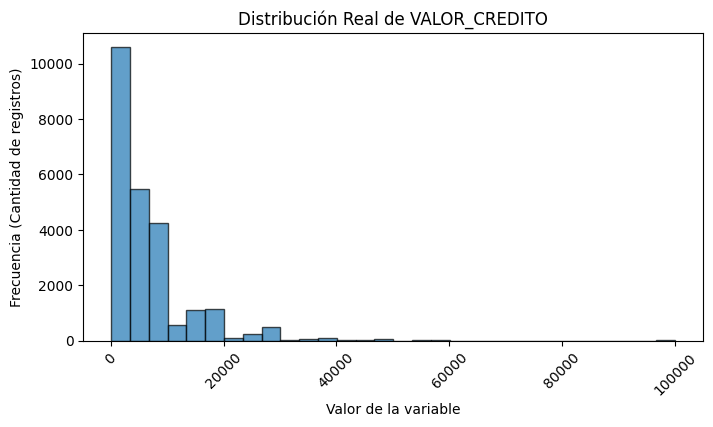

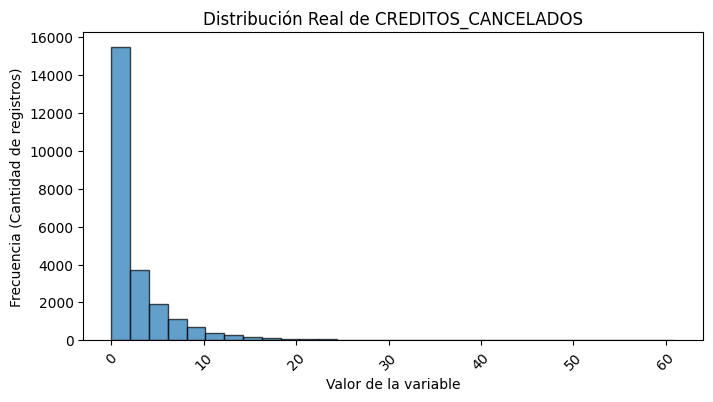

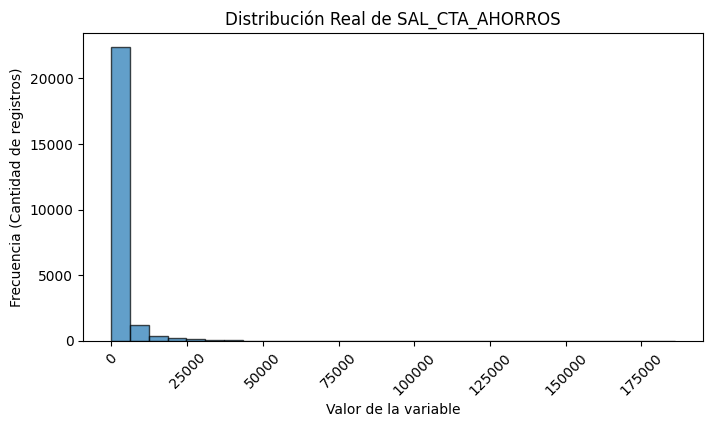

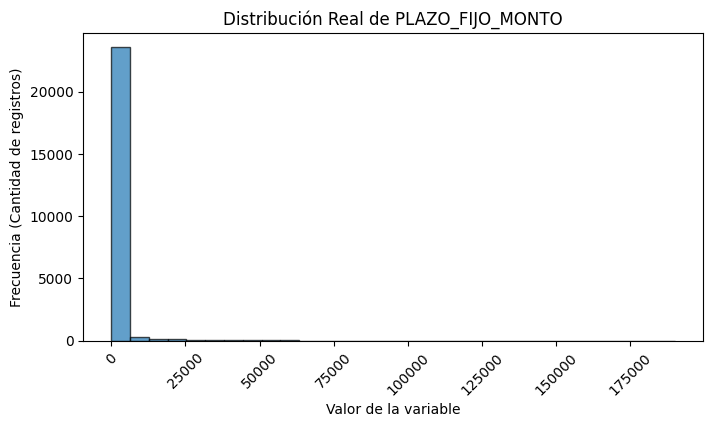

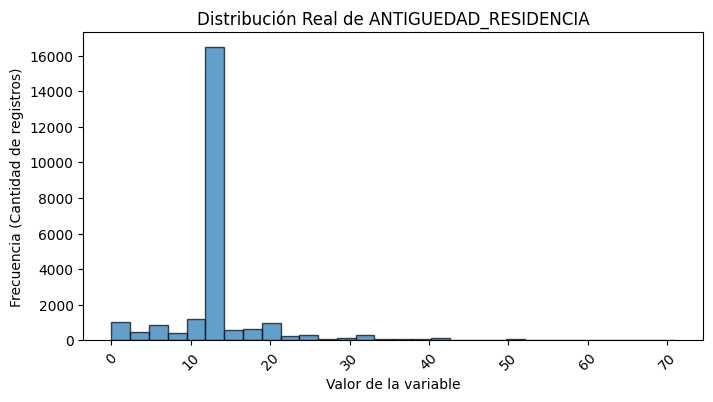

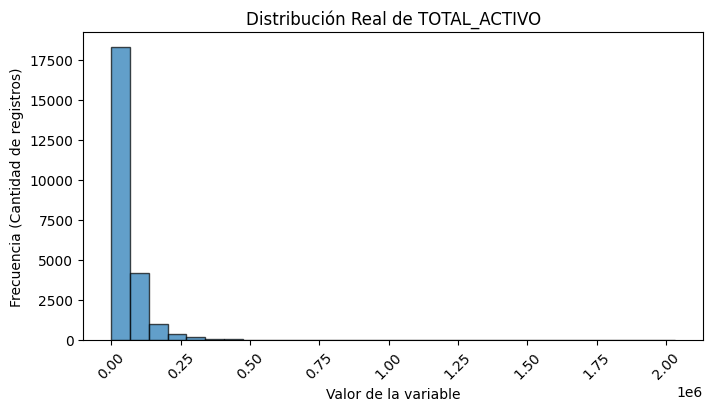

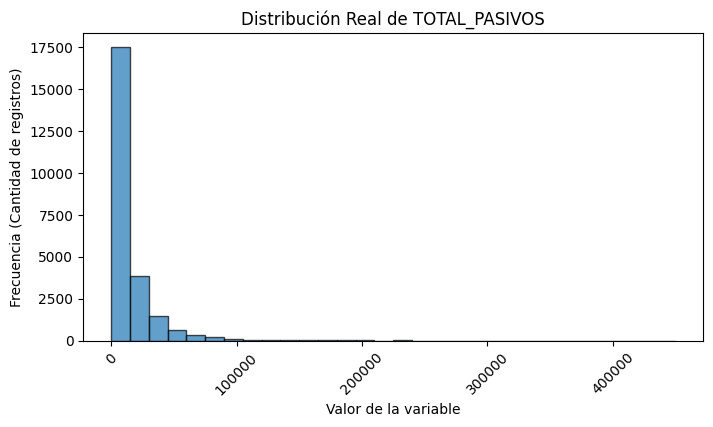

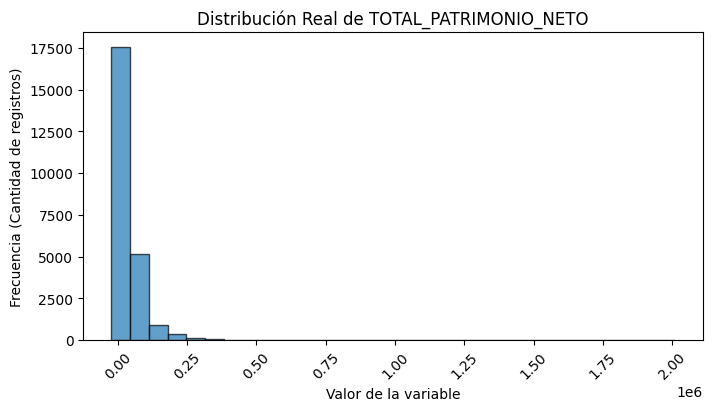

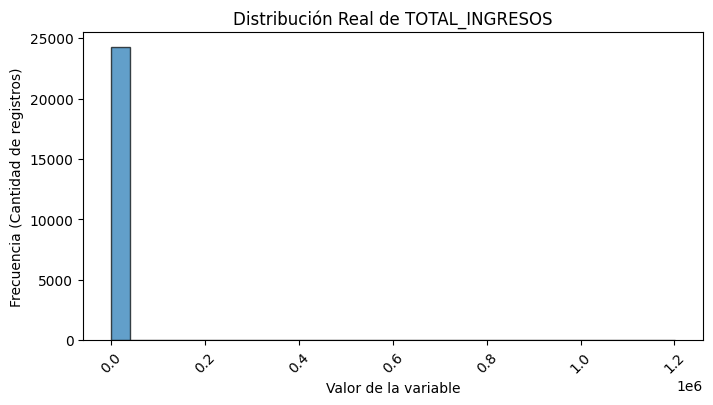

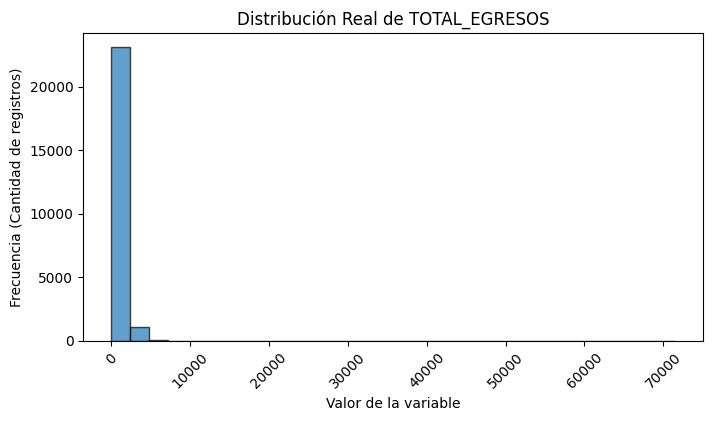

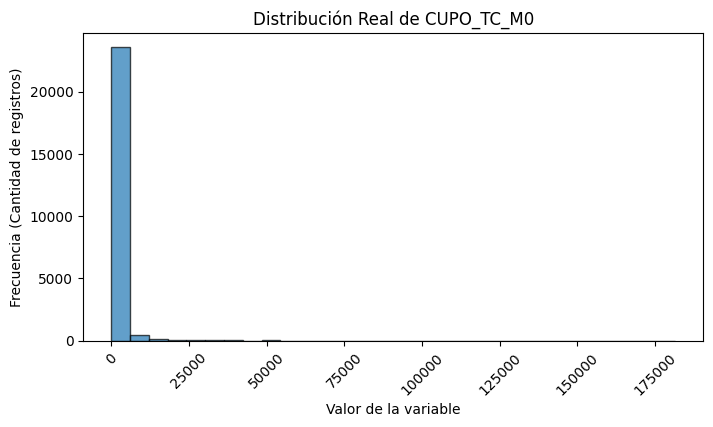

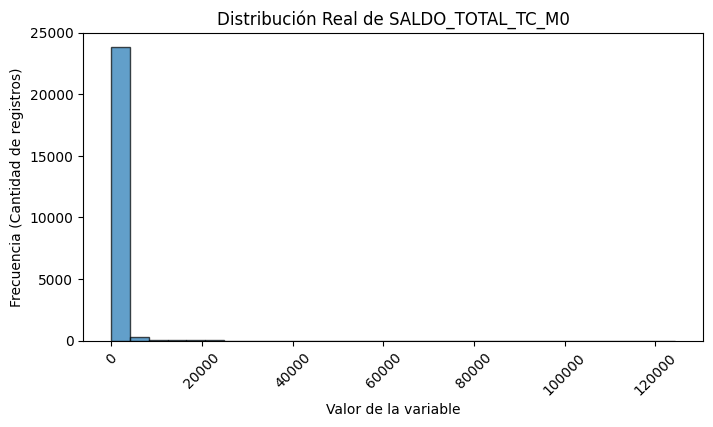

In [ ]:
for col in cols_outliers:
    plt.figure(figsize=(8, 4))
    plt.hist(df_clean[col], bins=30, edgecolor='black', alpha=0.7)

    plt.title(f'Distribución Real de {col}')
    plt.xlabel('Valor de la variable')
    plt.ylabel('Frecuencia (Cantidad de registros)')
    plt.xticks(rotation=45)
    plt.show()

Vamos a transformar todas las columnas menos Antiguedad_residencia y Creditos cancelados usando logaritmos

In [ ]:
# Creamos una copia para el tratamiento de outliers y mantener integridad del df original
df_so = df_clean.copy()

# Variables con asimetría extrema (monetarias/escala) que requieren logaritmo
cols_log = [
    'VALOR_CREDITO', 'TOTAL_INGRESOS', 'TOTAL_ACTIVO', 'TOTAL_PASIVOS',
    'TOTAL_PATRIMONIO_NETO', 'TOTAL_EGRESOS', 'SAL_CTA_AHORROS',
    'PLAZO_FIJO_MONTO', 'CUPO_TC_M0', 'SALDO_TOTAL_TC_M0'
]

Comprobamos las columnas con negativos, ya que no se puede aplicar logaritmo a negativos.

In [ ]:
for col in cols_log:
    if (df_so[col] < 0).any():
        print(f" {col}, tiene negativos")

 TOTAL_PATRIMONIO_NETO, tiene negativos
 SAL_CTA_AHORROS, tiene negativos


Para transformar las que tienen negativos, aplicamos la transformación con su valor absoluto multiplicandola por su signo.

In [ ]:
for col in ['TOTAL_PATRIMONIO_NETO', 'SAL_CTA_AHORROS']:
    df_so[col + '_log'] = np.sign(df_so[col]) * np.log1p(np.abs(df_so[col]))

In [ ]:
df_so[['TOTAL_PATRIMONIO_NETO_log', 'SAL_CTA_AHORROS_log']].head()

,TOTAL_PATRIMONIO_NETO_log,SAL_CTA_AHORROS_log
0,12.055491,5.985472
1,9.191769,7.046090
2,11.149772,6.930319
3,11.285021,7.794028
4,10.898433,3.332562


Ahora transformamos las variables numericas.

In [ ]:
cols_log = [
    'VALOR_CREDITO', 'TOTAL_INGRESOS', 'TOTAL_ACTIVO', 'TOTAL_PASIVOS',
    'TOTAL_EGRESOS', 'PLAZO_FIJO_MONTO', 'CUPO_TC_M0', 'SALDO_TOTAL_TC_M0'
]

for col in cols_log:
    df_so[col + '_log'] = np.log1p(df_so[col])

In [ ]:
df_so[cols_log].head()


,VALOR_CREDITO,TOTAL_INGRESOS,TOTAL_ACTIVO,TOTAL_PASIVOS,TOTAL_EGRESOS,PLAZO_FIJO_MONTO,CUPO_TC_M0,SALDO_TOTAL_TC_M0
0,4000.0,1203.29,176777.72,4737.17,445.50,0.0,0.0,0.00
1,6000.0,1170.00,14660.00,4845.00,858.00,0.0,5500.0,533.36
2,3000.0,2243.19,160975.40,91428.43,1988.24,10100.0,0.0,0.00
3,4000.0,1200.00,87750.00,8131.00,935.00,0.0,1120.0,0.00
4,3000.0,1485.00,64560.00,10469.49,1044.00,0.0,1500.0,549.99


In [ ]:
df_so.filter(like='_log').head()

,TOTAL_PATRIMONIO_NETO_log,SAL_CTA_AHORROS_log,VALOR_CREDITO_log,TOTAL_INGRESOS_log,TOTAL_ACTIVO_log,TOTAL_PASIVOS_log,TOTAL_EGRESOS_log,PLAZO_FIJO_MONTO_log,CUPO_TC_M0_log,SALDO_TOTAL_TC_M0_log
0,12.055491,5.985472,8.294300,7.093645,12.082654,8.463406,6.101439,0.00000,0.000000,0.000000
1,9.191769,7.046090,8.699681,7.065613,9.592946,8.485909,6.755769,0.00000,8.612685,6.281070
2,11.149772,6.930319,8.006701,7.716100,11.989013,11.423323,7.595508,9.22039,0.000000,0.000000
3,11.285021,7.794028,8.294300,7.090910,11.382259,9.003562,6.841615,0.00000,7.021976,0.000000
4,10.898433,3.332562,8.006701,7.303843,11.075366,9.256316,6.951772,0.00000,7.313887,6.311717


Listo con esto ya tenemos un data set con los valores originales, pero también con los valores con logaritmos lo cual reduce los outliers.

# Parte 2: RD mensual (columna default)

## 1. Calcular RD (tasa de default) por CODMES

In [ ]:
rd_codmes = df_so.groupby('CODMES')['DEFAULT'].mean().reset_index()
rd_codmes

,CODMES,DEFAULT
0,202008,1.281713
1,202009,3.213875
2,202010,1.322745
3,202011,3.294179
4,202012,1.501867
5,202101,1.359768
6,202102,1.424911
7,202103,1.483965
8,202104,1.393368
9,202105,1.414308


In [ ]:
import plotly.express as px

fig = px.line(
    rd_codmes,
    x='CODMES',
    y='DEFAULT',
    title='Evolución del Default Rate (RD) por CODMES',
    markers=True
)

fig.show()

## Interpretación

El default rate generalmente fluctúa entre 1.25 y 1.5. Sin embargo, en septiembre y noviembre de 2020 se observa un incremento sustancial, lo que sugiere la presencia de factores atípicos que deberían analizarse, ya sean internos (cambios en políticas de crédito) o externos (contexto económico).

Durante 2021, el indicador retorna a niveles más estables, manteniéndose dentro de un rango consistente. En general, no se identifica una tendencia creciente o decreciente sostenida, sino una fase inicial de volatilidad seguida de un comportamiento más controlado.


# Parte 3: Partición de datos

In [ ]:
#Primero veo cuantos registros hay por mes para asegurarme de particionar bien

In [ ]:
conteo = df_so.groupby('CODMES').size().reset_index(name='n_registros')
conteo['pct'] = conteo['n_registros'] / conteo['n_registros'].sum()
conteo

,CODMES,n_registros,pct
0,202008,2499,0.102873
1,202009,2436,0.100280
2,202010,2361,0.097192
3,202011,1924,0.079203
4,202012,1875,0.077186
5,202101,1551,0.063848
6,202102,1678,0.069076
7,202103,2058,0.084719
8,202104,1749,0.071999
9,202105,1943,0.079985


Ahora voy a tratar de dividir el archivo en 60-20-20.

In [ ]:
df_so['CODMES'] = df_so['CODMES'].astype(int)

In [ ]:
# Quiero crear una flag para los meses pico por si eso afecta mi modelo

In [ ]:
df_so['MES_PICO'] = df_so['CODMES'].isin([202009, 202011]).astype(int)

In [ ]:
# Train
train = df_so[df_so['CODMES'] <= 202101]

# Test
test = df_so[(df_so['CODMES'] >= 202102) & (df_so['CODMES'] <= 202104)]

# OOT
oot = df_so[df_so['CODMES'] >= 202105]

La partición se realizó de manera temporal utilizando la variable CODMES, asignando aproximadamente un 60% de los datos al conjunto de entrenamiento, 20% al conjunto de validación (test) y 20% al conjunto out-of-time (OOT). Al tener poca data quiero asegurarme de contar con suficiente data para poder hacer las pruebas de Test y de OOT.

# Part 4: Validación entre datasets

## Análisis de variables categóricas

In [ ]:
# 1. Identificar las columnas categóricas
cols_categoricas = df_so.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Mostrar la lista y un resumen rápido
print(f"Variables categóricas encontradas ({len(cols_categoricas)}):")
print(cols_categoricas)

# 3. Ver cuántas categorías únicas tiene cada una (para detectar si hay errores o demasiada variedad)
for col in cols_categoricas:
    print(f"{col}: {df_so[col].nunique()} valores únicos")

Variables categóricas encontradas (13):
['TIPO_ID', 'TIPO', 'ACTIVIDAD_ECONOMICA', 'PROVINCIA_ACTIVIDAD', 'CANTON_ACTIVIDAD', 'FECHA_NACIMIENTO', 'SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACION', 'TIPO_VIVIENDA', 'MARCA_CELULAR', 'FECHA_1RA_OPERACION', 'GARANTIA']
TIPO_ID: 2 valores únicos
TIPO: 6 valores únicos
ACTIVIDAD_ECONOMICA: 115 valores únicos
PROVINCIA_ACTIVIDAD: 45 valores únicos
CANTON_ACTIVIDAD: 128 valores únicos
FECHA_NACIMIENTO: 11469 valores únicos
SEXO: 2 valores únicos
ESTADO_CIVIL: 5 valores únicos
NIVEL_EDUCACION: 10 valores únicos
TIPO_VIVIENDA: 4 valores únicos
MARCA_CELULAR: 3 valores únicos
FECHA_1RA_OPERACION: 2739 valores únicos
GARANTIA: 2 valores únicos


In [ ]:
# Convertimos a datetime
df_so['FECHA_NACIMIENTO'] = pd.to_datetime(df_so['FECHA_NACIMIENTO'])
df_so['FECHA_1RA_OPERACION'] = pd.to_datetime(df_so['FECHA_1RA_OPERACION'])

In [ ]:
# 1. Identificar las columnas categóricas
cols_categoricas = df_so.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Mostrar la lista y un resumen rápido
print(f"Variables categóricas encontradas ({len(cols_categoricas)}):")
print(cols_categoricas)

# 3. Ver cuántas categorías únicas tiene cada una (para detectar si hay errores o demasiada variedad)
for col in cols_categoricas:
    print(f"{col}: {df_so[col].nunique()} valores únicos")

Variables categóricas encontradas (11):
['TIPO_ID', 'TIPO', 'ACTIVIDAD_ECONOMICA', 'PROVINCIA_ACTIVIDAD', 'CANTON_ACTIVIDAD', 'SEXO', 'ESTADO_CIVIL', 'NIVEL_EDUCACION', 'TIPO_VIVIENDA', 'MARCA_CELULAR', 'GARANTIA']
TIPO_ID: 2 valores únicos
TIPO: 6 valores únicos
ACTIVIDAD_ECONOMICA: 115 valores únicos
PROVINCIA_ACTIVIDAD: 45 valores únicos
CANTON_ACTIVIDAD: 128 valores únicos
SEXO: 2 valores únicos
ESTADO_CIVIL: 5 valores únicos
NIVEL_EDUCACION: 10 valores únicos
TIPO_VIVIENDA: 4 valores únicos
MARCA_CELULAR: 3 valores únicos
GARANTIA: 2 valores únicos


In [ ]:
from scipy.stats import chi2_contingency

def calcular_cramers_v(contingency):
    """Calcula el coeficiente V de Cramer para una tabla de contingencia."""
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    # Corrección para sesgo en tablas pequeñas (opcional pero recomendada)
    return np.sqrt(phi2 / min(k - 1, r - 1))

results = []

# Iteramos sobre las variables categóricas
for col in cols_categoricas:
    # Creamos la tabla cruzada con el target
    contingency = pd.crosstab(df_so[col], df_so['DEFAULT'])

    # Ejecutamos Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Calculamos Cramer's V
    v = calcular_cramers_v(contingency)

    results.append({
        'variable': col,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': v,
        'significativa': p < 0.05
    })

# Convertir a DataFrame
chi_df = pd.DataFrame(results)

# Formatear p_value para legibilidad (evitar notación científica extrema)
chi_df['p_value'] = chi_df['p_value'].apply(lambda x: f"{x:.4f}")

# Ordenar por Cramer's V de mayor a menor (las más importantes arriba)
chi_df = chi_df.sort_values(by='cramers_v', ascending=False)

# Resetear el índice
chi_df = chi_df.reset_index(drop=True)


chi_df

,variable,chi2,p_value,cramers_v,significativa
0,PROVINCIA_ACTIVIDAD,1567.134070,0.0000,0.146643,True
1,TIPO,1485.693536,0.0000,0.142782,True
2,CANTON_ACTIVIDAD,1368.260264,0.0000,0.137023,True
3,TIPO_ID,410.484686,0.0000,0.129992,True
4,ACTIVIDAD_ECONOMICA,1136.523034,0.0000,0.124881,True
5,ESTADO_CIVIL,147.420184,0.0000,0.044977,True
6,SEXO,38.926410,0.0000,0.040030,True
7,TIPO_VIVIENDA,111.207411,0.0000,0.039064,True
8,NIVEL_EDUCACION,80.142527,0.0000,0.033162,True
9,GARANTIA,13.020908,0.0046,0.023152,True


## Análisis de variables númericas

Voy a crear dos nuevas variables númericas: edad y tiempo de antiguedad.

In [ ]:
#uso el año 2021 que es el año del dataset

df_so['EDAD'] = 2021 - pd.to_datetime(df_so['FECHA_NACIMIENTO']).dt.year

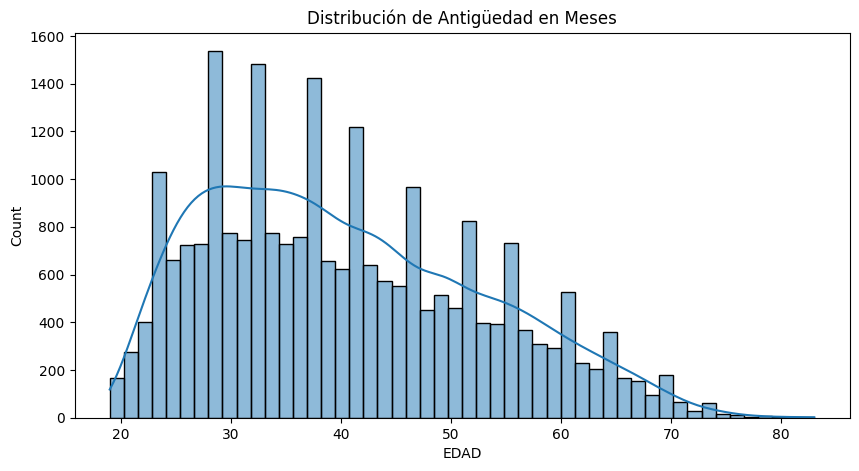

In [ ]:
# Grafico la distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_so['EDAD'], bins=50, kde=True)
plt.title('Distribución de Antigüedad en Meses')
plt.show()

In [ ]:
# Calculamos meses totales hasta el cierre de 2021 (Diciembre)
df_so['ANTIGUEDAD_MESES'] = (2021 - df_so['FECHA_1RA_OPERACION'].dt.year) * 12 + (12 - df_so['FECHA_1RA_OPERACION'].dt.month)

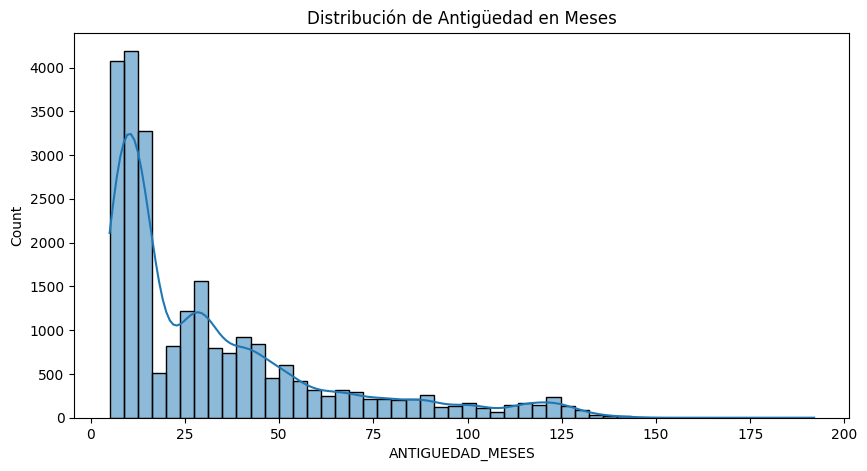

In [ ]:
# Grafico la distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_so['ANTIGUEDAD_MESES'], bins=50, kde=True)
plt.title('Distribución de Antigüedad en Meses')
plt.show()

In [ ]:
corr = df_so.corr(numeric_only=True)['DEFAULT'].sort_values(ascending=False)
corr

,DEFAULT
DEFAULT,1.000000
MES_PICO,0.419640
CREDITOS_ACTIVOS,0.265904
NUM_OPERACIONES,0.264349
CREDITOS_CANCELADOS,0.173120
ANTIGUEDAD_MESES,0.110061
CREDITOS_ATRASOS,0.079671
PLAZO_FIJO_MONTO_log,0.077108
PLAZO_FIJO,0.072016
TOTAL_EGRESOS_log,0.057803


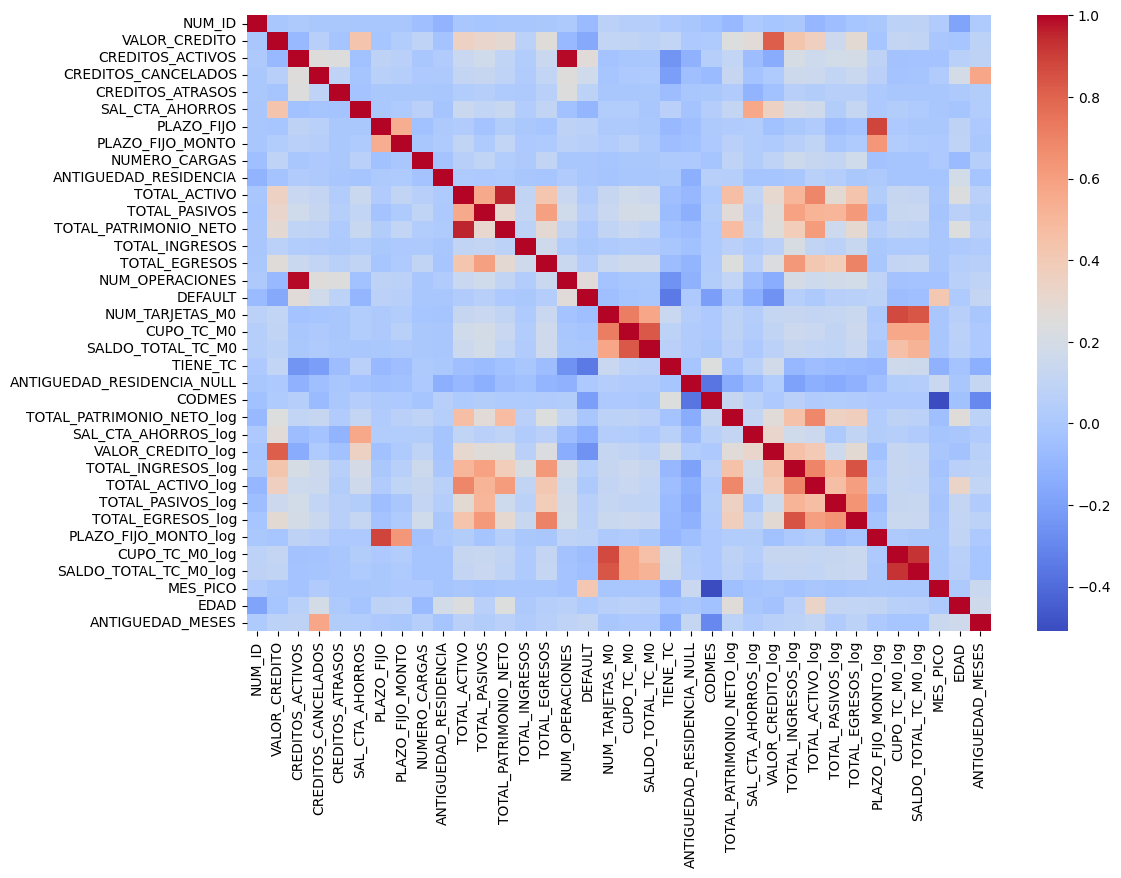

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df_so.corr(numeric_only=True), cmap='coolwarm')
plt.show()

Como cree nuevas variables vuelvo a particionar para poder incluirlas.

In [ ]:
# Train
train = df_so[df_so['CODMES'] <= 202101]

# Test
test = df_so[(df_so['CODMES'] >= 202102) & (df_so['CODMES'] <= 202104)]

# OOT
oot = df_so[df_so['CODMES'] >= 202105]

## Comparar RD (Default Rate)

In [ ]:
# Calculamos los RD por separado
rd_train_total = train['DEFAULT'].mean()
rd_train_pico = train[train['MES_PICO'] == 1]['DEFAULT'].mean()
rd_train_normal = train[train['MES_PICO'] == 0]['DEFAULT'].mean()

rd_test = test['DEFAULT'].mean()
rd_oot = oot['DEFAULT'].mean()

# Creamos el DataFrame comparativo
rd_df = pd.DataFrame({
    'dataset': ['Train (Total)', 'Train (Solo Picos)', 'Train (Normal)', 'Test', 'OOT'],
    'RD (%)': [rd_train_total * 100, rd_train_pico * 100, rd_train_normal * 100, rd_test * 100, rd_oot * 100]
}).round(4)

rd_df

,dataset,RD (%)
0,Train (Total),200.9964
1,Train (Solo Picos),324.9312
2,Train (Normal),135.7832
3,Test,143.7010
4,OOT,137.1531


Podemos ver que en general train (normal), test y OOY son consistentes con el nivel de RD. Sin embargo, el conjunto train se ve afectado ya que tiene dos meses pico en su interior.

## Comparar volumen (VALOR_CREDITO)

In [ ]:
# 1. Definimos los subconjuntos
datasets = {
    'Train (Total)': train,
    'Train (Solo Picos)': train[train['MES_PICO'] == 1],
    'Train (Normal)': train[train['MES_PICO'] == 0],
    'Test': test,
    'OOT': oot
}

results = []

for name, df in datasets.items():
    # Calculamos el ticket promedio de cada mes individualmente en este dataset
    # Si el dataset está vacío (evitar errores), devolvemos 0
    if not df.empty:
        ticket_prom_mensual = df.groupby('CODMES')['VALOR_CREDITO'].mean().mean()
    else:
        ticket_prom_mensual = 0

    results.append({
        'Dataset': name,
        'Nro_Creditos': len(df),
        'Volumen_Total': df['VALOR_CREDITO'].sum(),
        'Ticket_Prom_Cliente': df['VALOR_CREDITO'].mean(), # Promedio simple por registro
        'Ticket_Prom_Mes': ticket_prom_mensual,           # Promedio de los meses
        'Default_Rate (%)': df['DEFAULT'].mean() * 100
    })

# 2. Creamos el DataFrame comparativo
vol_df = pd.DataFrame(results)

# 3. Formateamos y mostramos
pd.options.display.float_format = '{:,.2f}'.format
vol_df

,Dataset,Nro_Creditos,Volumen_Total,Ticket_Prom_Cliente,Ticket_Prom_Mes,Default_Rate (%)
0,Train (Total),12646,"85,984,591.34","6,799.35","6,760.83",201.00
1,Train (Solo Picos),4360,"29,752,231.60","6,823.91","6,803.90",324.93
2,Train (Normal),8286,"56,232,359.74","6,786.43","6,739.30",135.78
3,Test,5485,"37,726,029.13","6,878.04","6,896.34",143.70
4,OOT,6161,"45,379,378.64","7,365.59","7,341.23",137.15


Vemos que el ticket promedio ha aumentado en los últimos 3 meses.

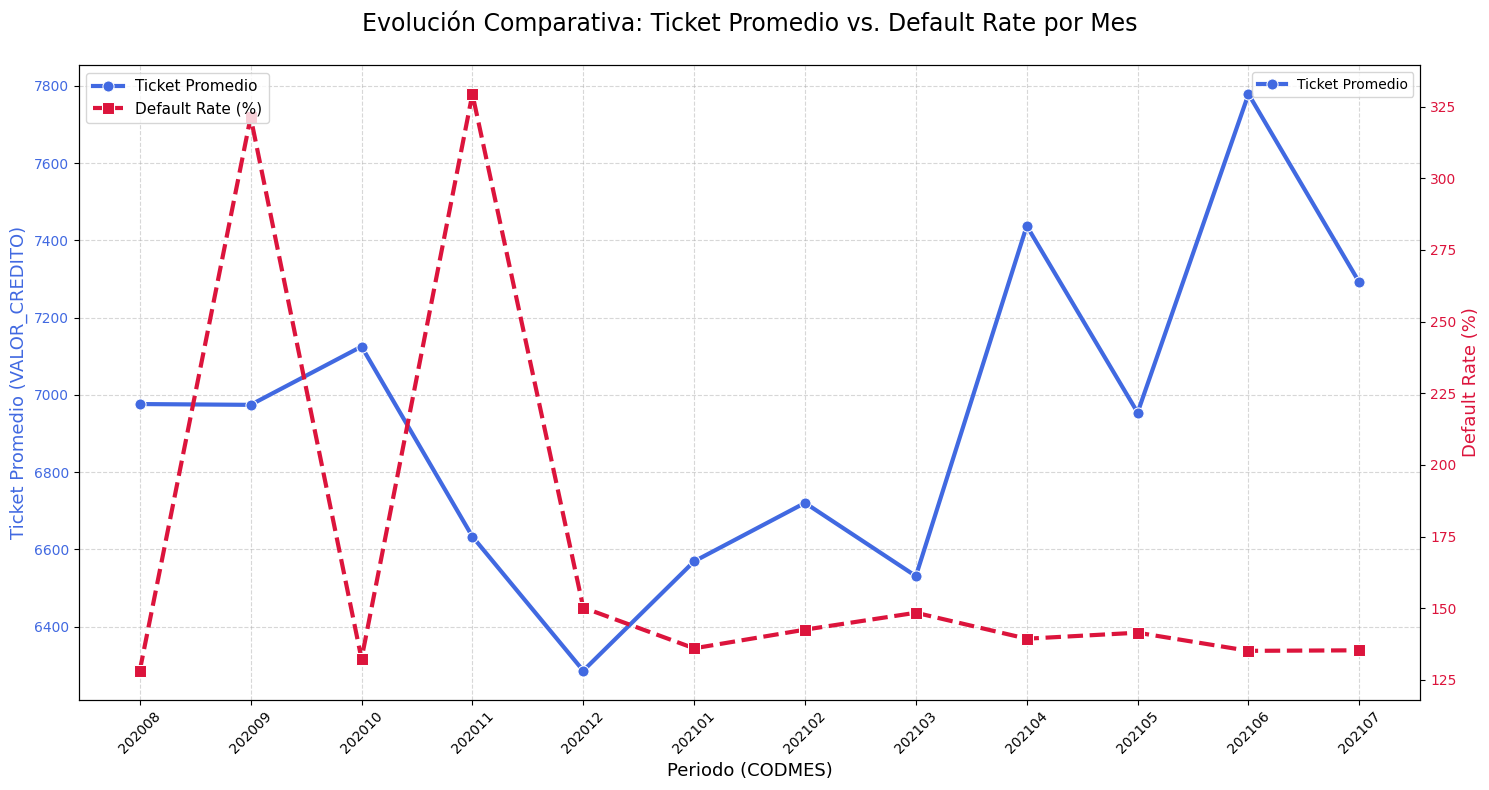

In [ ]:

# 1. Agregamos la data por CODMES (Promedio de Valor de Crédito y Promedio de Default)
df_plot = df_so.groupby('CODMES').agg({
    'VALOR_CREDITO': 'mean',
    'DEFAULT': 'mean'
}).reset_index()

# Multiplicamos el Default por 100 para que sea porcentaje (ej. 0.032 -> 3.2%)
df_plot['DEFAULT_PCT'] = df_plot['DEFAULT'] * 100
# Convertimos CODMES a string para un eje X categórico ordenado
df_plot['CODMES_STR'] = df_plot['CODMES'].astype(str)

# 2. Creamos la figura y el primer eje (Eje Y Izquierdo para Ticket Promedio)
fig, ax1 = plt.subplots(figsize=(15, 8))

# Línea para el Ticket Promedio (Eje Izquierdo - Azul)
sns.lineplot(data=df_plot, x='CODMES_STR', y='VALOR_CREDITO',
             marker='o', markersize=8, color='royalblue', linewidth=3,
             ax=ax1, label='Ticket Promedio')

# Configuración del Eje X y Y Izquierdo
ax1.set_xlabel('Periodo (CODMES)', fontsize=13)
ax1.set_ylabel('Ticket Promedio (VALOR_CREDITO)', color='royalblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='royalblue')
plt.xticks(rotation=45) # Rotar etiquetas X

# 3. Creamos el segundo eje Y (Eje Y Derecho para Default Rate)
ax2 = ax1.twinx()

# Línea para el Default Rate (Eje Derecho - Rojo)
sns.lineplot(data=df_plot, x='CODMES_STR', y='DEFAULT_PCT',
             marker='s', markersize=8, color='crimson', linewidth=3, linestyle='--',
             ax=ax2, label='Default Rate (%)')

# Configuración del Eje Y Derecho
ax2.set_ylabel('Default Rate (%)', color='crimson', fontsize=13)
ax2.tick_params(axis='y', labelcolor='crimson')

# 4. Título, Grilla y Detalles finales
plt.title('Evolución Comparativa: Ticket Promedio vs. Default Rate por Mes', fontsize=17, pad=25)
ax1.grid(axis='both', linestyle='--', alpha=0.5)

# Combinar leyendas de ambos ejes en una sola
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

De manera gráfica podemos comprobar que el ticket promedio ha ido aumentando desde diciembre de 2020.

## Comparar NUM_OPERACIONES

In [ ]:
results = []

for name, df in datasets.items():
    if not df.empty:
        # 1. Promedio de operaciones por mes (Agrupando por CODMES)
        # Sumamos las operaciones de cada mes y luego promediamos esos totales
        ops_prom_mes = df.groupby('CODMES')['NUM_OPERACIONES'].sum().mean()

        # 2. Intensidad operativa (¿Cuántas operaciones tiene el cliente promedio?)
        intensidad_cliente = df['NUM_OPERACIONES'].mean()
    else:
        nro_registros = total_ops_volumen = ops_prom_mes = intensidad_cliente = 0

    results.append({
        'Dataset': name,
        'Ops_Promedio_Mes': ops_prom_mes,
        'Intensidad_por_Cliente': intensidad_cliente,
        'Default_Rate (%)': df['DEFAULT'].mean() * 100
    })

# Crear y mostrar DataFrame
ops_df = pd.DataFrame(results)
pd.options.display.float_format = '{:,.2f}'.format

ops_df

,Dataset,Ops_Promedio_Mes,Intensidad_por_Cliente,Default_Rate (%)
0,Train (Total),"2,414.17",1.15,201.00
1,Train (Solo Picos),"2,475.50",1.14,324.93
2,Train (Normal),"2,383.50",1.15,135.78
3,Test,"2,157.33",1.18,143.70
4,OOT,"2,380.00",1.16,137.15


Como podemos ver la cantidad de operaciones por cliente (Intensidad_por_Cliente) se manteiene constante y en general las operaciones por mes también se mantienen costantes.

# Parte 5: Modelo

Mis variables candidatas son:


Numericas:

MES_PICO	0.419640

CREDITOS_ACTIVOS	0.265904

NUM_OPERACIONES	0.264349

CREDITOS_CANCELADOS	0.173120

ANTIGUEDAD_MESES	0.110061

SAL_CTA_AHORROS	-0.099197

SAL_CTA_AHORROS_log	-0.134532

VALOR_CREDITO	-0.160486

CODMES	-0.204816

VALOR_CREDITO_log	-0.259491

TIENE_TC	-0.344431


De las numericas descarto num_operaciones ya que tiene una correlación muy alta con creditos activos.

Me quedo con la versión logaritmica de sal_cta_ahorros y valor_credito.

Borro CODMES.

MES_PICO	0.419640

TIENE_TC	-0.344431

CREDITOS_ACTIVOS	0.265904

CREDITOS_CANCELADOS	0.173120

ANTIGUEDAD_MESES	0.110061

SAL_CTA_AHORROS_log	-0.134532

VALOR_CREDITO_log	-0.259491



Categoricas:

	variable	chi2	p_value	cramers_v	significativa
0	PROVINCIA_ACTIVIDAD	1567.134070	0.0000	0.146643	True

1	TIPO	1485.693536	0.0000	0.142782	True

2	CANTON_ACTIVIDAD	1368.260264	0.0000	0.137023	True

3	TIPO_ID	410.484686	0.0000	0.129992	True

4	ACTIVIDAD_ECONOMICA	1136.523034	0.0000	0.124881	True

5	ESTADO_CIVIL	147.420184	0.0000	0.044977	True

6	SEXO	38.926410	0.0000	0.040030	True

7	TIPO_VIVIENDA	111.207411	0.0000	0.039064	True

8	NIVEL_EDUCACION	80.142527	0.0000	0.033162	True

9	GARANTIA	13.020908	0.0046	0.023152	True

10	MARCA_CELULAR	24.470779	0.0004	0.022443	True

Voy a descartar por cramers_v las que sean menores de 0.1 para no hacer overfitting.

Y por posible redundancia me voy a quedar con provincia_actividad y voy a descartar canton actividad.

0	PROVINCIA_ACTIVIDAD	1567.134070	0.0000	0.146643	True

1	TIPO	1485.693536	0.0000	0.142782	True

3	TIPO_ID	410.484686	0.0000	0.129992	True

4	ACTIVIDAD_ECONOMICA	1136.523034	0.0000	0.124881	True


In [ ]:
# El problema es que tenemos variables categoricas con muchos tipos de datos, por lo que vamos a ver primero la distribución
# PROVINCIA_ACTIVIDAD: 45 valores únicos
# ACTIVIDAD_ECONOMICA: 115 valores únicos

## Reducción de Cardinalidad

/tmp/ipykernel_1690/812289049.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



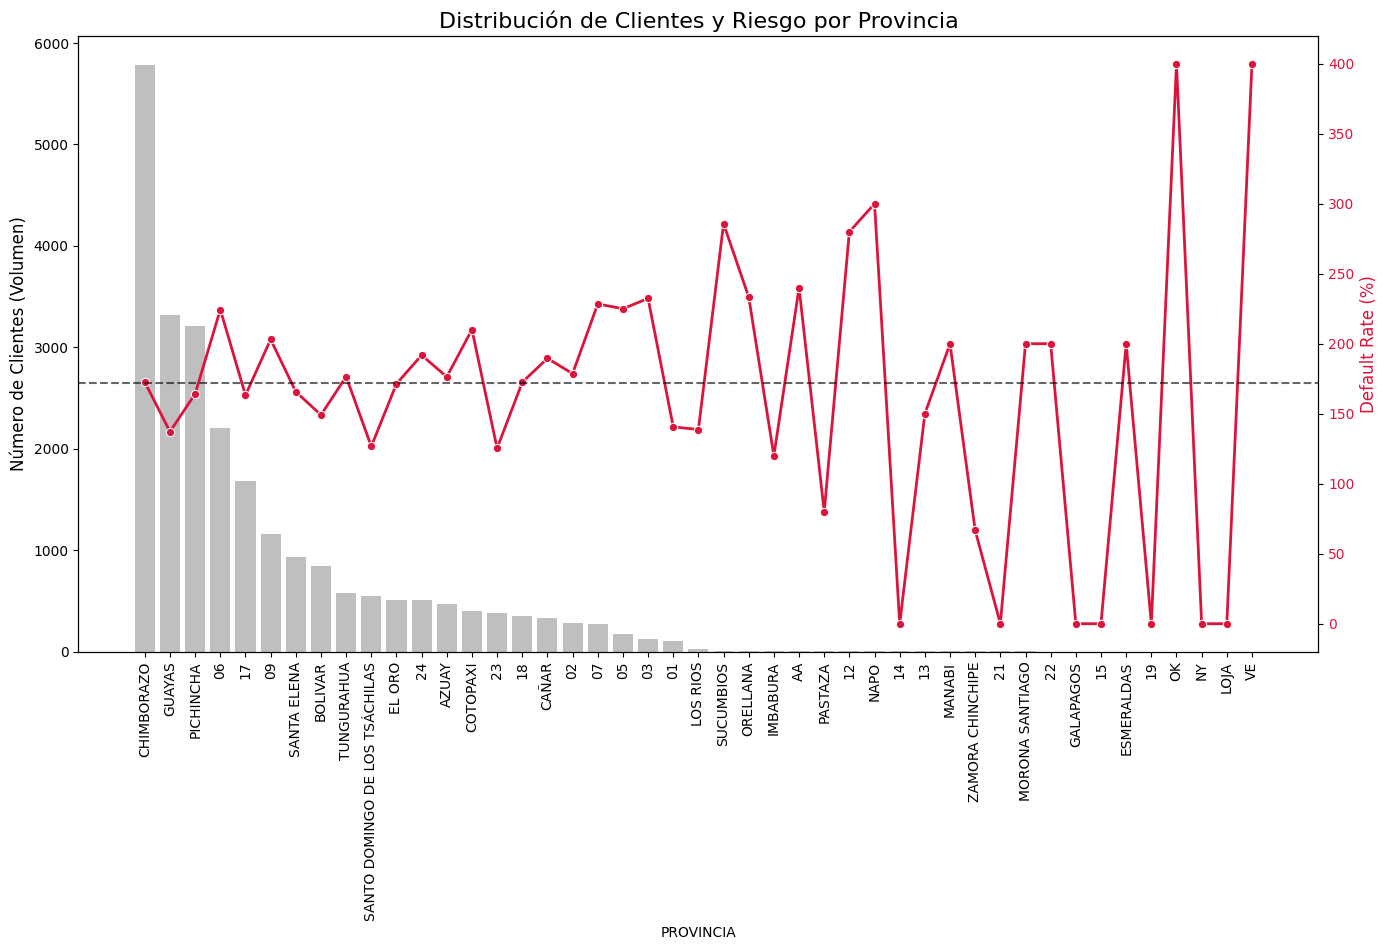

In [ ]:
# 1. Agrupamos la data por Provincia
prov_dist = df_so.groupby('PROVINCIA_ACTIVIDAD').agg({
    'DEFAULT': ['count', 'mean']
}).reset_index()

# Renombramos columnas para facilidad
prov_dist.columns = ['PROVINCIA', 'NRO_CLIENTES', 'DEFAULT_RATE']
prov_dist['DEFAULT_RATE'] *= 100  # Convertir a porcentaje

# Ordenamos por número de clientes para ver la relevancia comercial
prov_dist = prov_dist.sort_values(by='NRO_CLIENTES', ascending=False)

# 2. Graficamos
fig, ax1 = plt.subplots(figsize=(16, 8))

# Eje 1: Barras para cantidad de clientes
sns.barplot(data=prov_dist, x='PROVINCIA', y='NRO_CLIENTES', alpha=0.5, color='gray', ax=ax1)
ax1.set_ylabel('Número de Clientes (Volumen)', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# Eje 2: Línea para Default Rate
ax2 = ax1.twinx()
sns.lineplot(data=prov_dist, x='PROVINCIA', y='DEFAULT_RATE', marker='o', color='crimson', linewidth=2, ax=ax2)
ax2.set_ylabel('Default Rate (%)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

# Línea de referencia: Promedio global de Default
avg_default = df_so['DEFAULT'].mean() * 100
ax2.axhline(avg_default, color='black', linestyle='--', alpha=0.6, label=f'Promedio Global ({avg_default:.2f}%)')

plt.title('Distribución de Clientes y Riesgo por Provincia', fontsize=16)
plt.show()

/tmp/ipykernel_1690/920548480.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



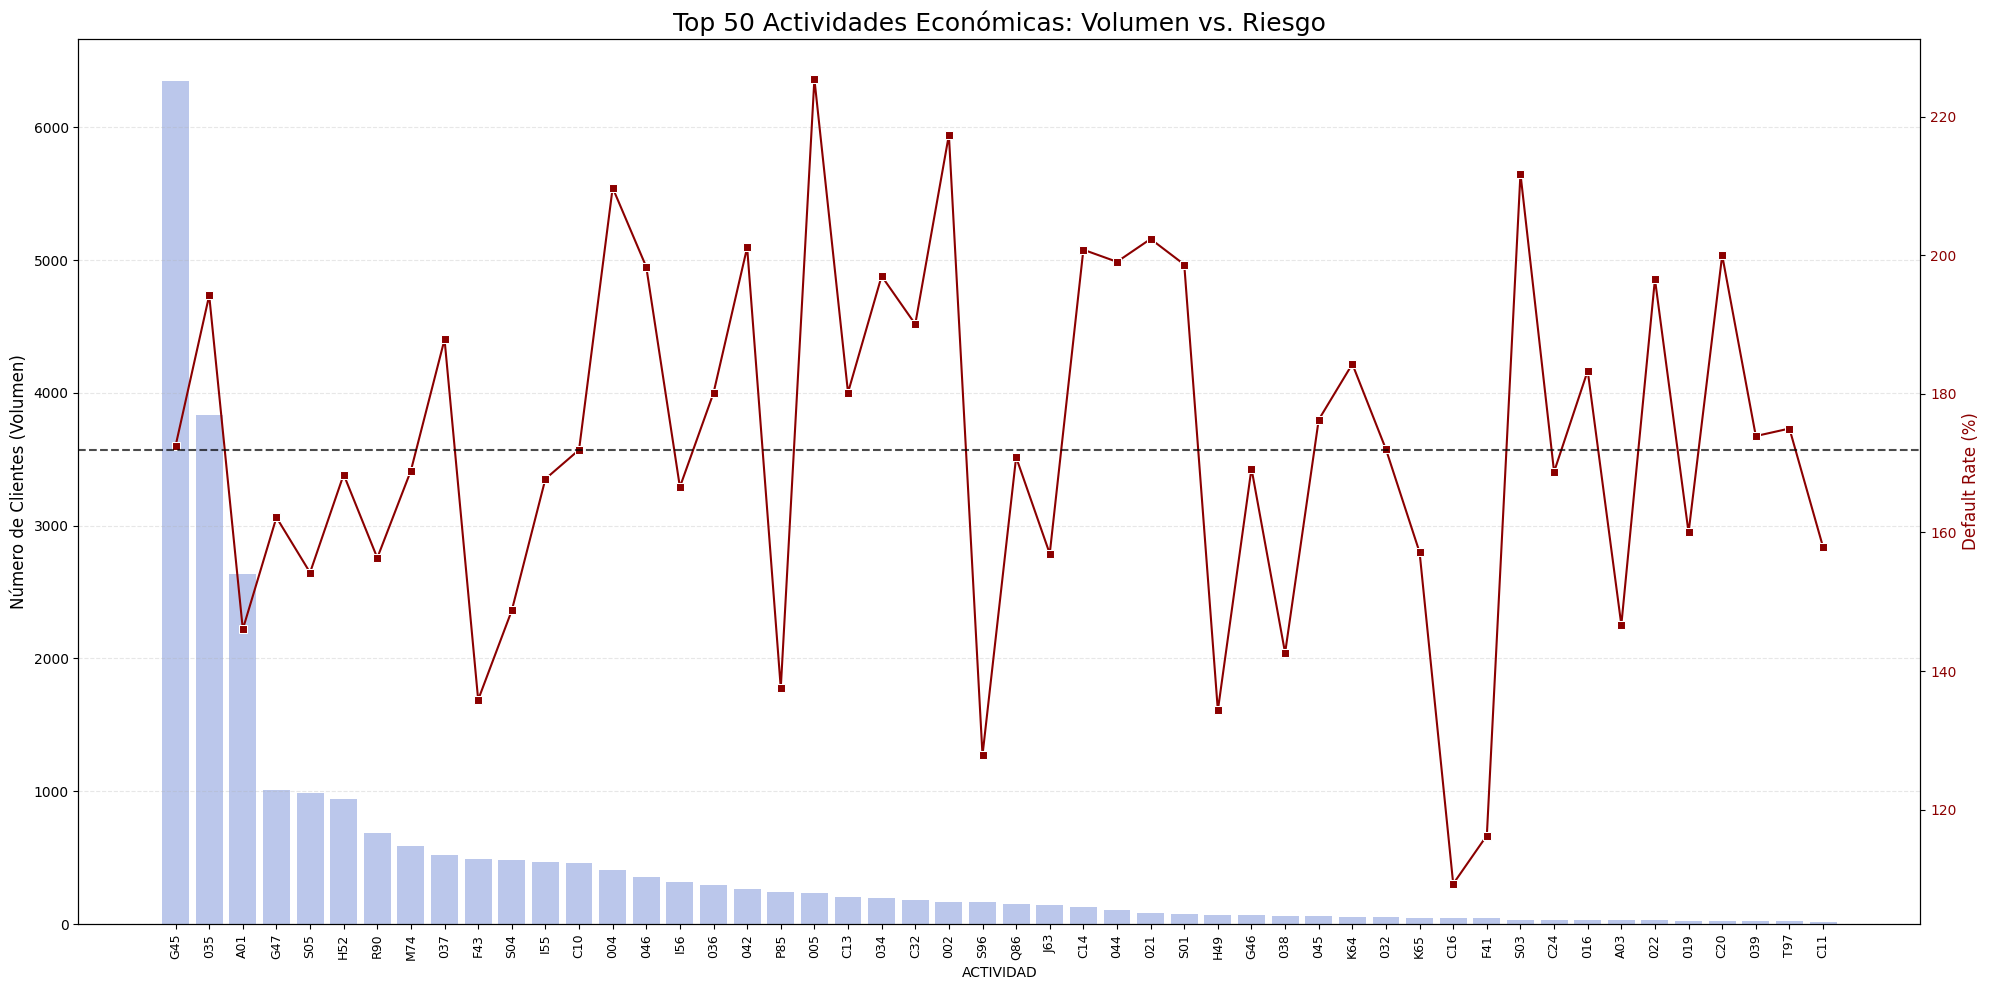

In [ ]:
# 1. Agrupamos la data por Actividad Económica
act_dist = df_so.groupby('ACTIVIDAD_ECONOMICA').agg({
    'DEFAULT': ['count', 'mean']
}).reset_index()

# Renombramos columnas
act_dist.columns = ['ACTIVIDAD', 'NRO_CLIENTES', 'DEFAULT_RATE']
act_dist['DEFAULT_RATE'] *= 100

# Ordenamos por volumen (las actividades más frecuentes primero)
act_dist = act_dist.sort_values(by='NRO_CLIENTES', ascending=False)

# 2. Graficamos (Solo las Top 50 para que sea legible, o quita el [:50] para ver las 115)
fig, ax1 = plt.subplots(figsize=(20, 10))

# Eje 1: Barras (Volumen)
sns.barplot(data=act_dist[:50], x='ACTIVIDAD', y='NRO_CLIENTES', alpha=0.4, color='royalblue', ax=ax1)
ax1.set_ylabel('Número de Clientes (Volumen)', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, fontsize=9)

# Eje 2: Línea (Riesgo)
ax2 = ax1.twinx()
sns.lineplot(data=act_dist[:50], x='ACTIVIDAD', y='DEFAULT_RATE', marker='s', color='darkred', linewidth=1.5, ax=ax2)
ax2.set_ylabel('Default Rate (%)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')

# Referencia: Promedio global
avg_default = df_so['DEFAULT'].mean() * 100
ax2.axhline(avg_default, color='black', linestyle='--', alpha=0.7, label=f'Promedio Global ({avg_default:.2f}%)')

plt.title('Top 50 Actividades Económicas: Volumen vs. Riesgo', fontsize=18)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Después de ver la distribución, me voy a quedar solo con las 6 variables más representativas. El resto las voy agrupar por si estan por debajo o por encima del promedio de riesgo. Y voy a tener en cuenta el promedio solo de train para no darle ese dato del futuro a los data sets de test y oot.

In [ ]:

# 1. REGLAS BASADAS ÚNICAMENTE EN TRAIN


# Promedio global de default en Train (nuestro benchmark)
media_global_train = train['DEFAULT'].mean()

# --- PROVINCIAS ---
top_prov = train['PROVINCIA_ACTIVIDAD'].value_counts().nlargest(6).index.tolist()
# Calculamos el riesgo por provincia en Train
riesgos_prov_train = train.groupby('PROVINCIA_ACTIVIDAD')['DEFAULT'].mean()

# --- ACTIVIDADES ---
top_act = train['ACTIVIDAD_ECONOMICA'].value_counts().nlargest(6).index.tolist()
# Calculamos el riesgo por actividad en Train
riesgos_act_train = train.groupby('ACTIVIDAD_ECONOMICA')['DEFAULT'].mean()


# 2. FUNCIÓN DE TRANSFORMACIÓN (REDUCCIÓN DE CARDINALIDAD)


def transformar_variables_riesgo(df_input):
    df_temp = df_input.copy()

    # Lógica para Provincia
    def categorizar_prov(val):
        if val in top_prov:
            return val
        # Si no es Top 6, buscamos su riesgo en el pasado (Train)
        # Si es una provincia nueva (no está en riesgos_prov_train),
        # le asignamos Riesgo Alto por política conservadora
        riesgo = riesgos_prov_train.get(val, media_global_train + 0.1)
        return 'Otros-Riesgo Alto' if riesgo > media_global_train else 'Otros-Riesgo Bajo'

    # Lógica para Actividad
    def categorizar_act(val):
        if val in top_act:
            return val
        # Si es nueva o no es Top 6, evaluamos riesgo histórico
        riesgo = riesgos_act_train.get(val, media_global_train + 0.1)
        return 'Otros-Riesgo Alto' if riesgo > media_global_train else 'Otros-Riesgo Bajo'

    # Creamos las nuevas columnas
    df_temp['PROVINCIA_MODELO'] = df_temp['PROVINCIA_ACTIVIDAD'].apply(categorizar_prov)
    df_temp['ACTIVIDAD_MODELO'] = df_temp['ACTIVIDAD_ECONOMICA'].apply(categorizar_act)

    return df_temp


# 3. APLICACIÓN


train = transformar_variables_riesgo(train)
test = transformar_variables_riesgo(test)
oot = transformar_variables_riesgo(oot)

# Verificación rápida del resultado
print("Categorías finales en Provincia:", train['PROVINCIA_MODELO'].nunique())
print("Categorías finales en Actividad:", train['ACTIVIDAD_MODELO'].nunique())

Categorías finales en Provincia: 8
Categorías finales en Actividad: 8


## Definir el target y las variables:

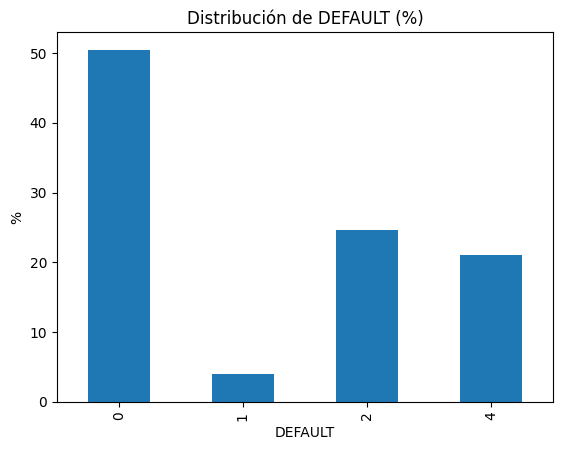

In [ ]:
(df["DEFAULT"].value_counts(normalize=True) * 100).sort_index().plot(kind='bar')

plt.title("Distribución de DEFAULT (%)")
plt.xlabel("DEFAULT")
plt.ylabel("%")
plt.show()

Como vemos que el default esta expresado en varias categorías vamos a simplicar a 0 y 1 para hacer la regresión logistica y vamos a probar otra tecnica considerando las 4 categorías originales (0,1,2,4)

In [ ]:
# --- ESTRATEGIA A: Y Binaria (Agrupada) ---
# 0 = Bueno, 1 = Riesgo (incluye 1, 2, 4 originales)
y_train = train['DEFAULT'].replace({2: 1, 4: 1})
y_test  = test['DEFAULT'].replace({2: 1, 4: 1})
y_oot   = oot['DEFAULT'].replace({2: 1, 4: 1})

# --- ESTRATEGIA B: Y Multiclase (Original) ---
# Se queda con 0, 1, 2, 4 para ver matices
y_train_multi = train['DEFAULT']
y_test_multi  = test['DEFAULT']
y_oot_multi   = oot['DEFAULT']

In [ ]:
# --- 2. Definir X (Features seleccionadas) ---
vars_numericas = ['MES_PICO', 'TIENE_TC', 'CREDITOS_ACTIVOS', 'CREDITOS_CANCELADOS',
                  'ANTIGUEDAD_MESES', 'SAL_CTA_AHORROS_log', 'VALOR_CREDITO_log']

vars_categoricas = ['PROVINCIA_MODELO', 'TIPO', 'TIPO_ID', 'ACTIVIDAD_MODELO']

features_modelo = vars_numericas + vars_categoricas

# Creamos los subsets de X
X_train = train[features_modelo].copy()
X_test  = test[features_modelo].copy()
X_oot   = oot[features_modelo].copy()

In [ ]:
X_train.dtypes

,0
MES_PICO,int64
TIENE_TC,int64
CREDITOS_ACTIVOS,int64
CREDITOS_CANCELADOS,int64
ANTIGUEDAD_MESES,int32
SAL_CTA_AHORROS_log,float64
VALOR_CREDITO_log,float64
PROVINCIA_MODELO,object
TIPO,object
TIPO_ID,object


In [ ]:
X_train.head()

,MES_PICO,TIENE_TC,CREDITOS_ACTIVOS,CREDITOS_CANCELADOS,ANTIGUEDAD_MESES,SAL_CTA_AHORROS_log,VALOR_CREDITO_log,PROVINCIA_MODELO,TIPO,TIPO_ID,ACTIVIDAD_MODELO
0,1,1,1,1,39,5.99,8.29,Otros-Riesgo Alto,MICROCREDITO ACUMULACIÓN SIMPLE,C,Otros-Riesgo Alto
1,1,1,1,0,13,7.05,8.70,Otros-Riesgo Alto,CONSUMO,C,Otros-Riesgo Alto
2,0,0,1,0,14,6.93,8.01,Otros-Riesgo Alto,CONSUMO PRIORITARIO,CED,037
3,0,1,1,4,12,7.79,8.29,CHIMBORAZO,MICROCREDITO ACUMULACIÓN SIMPLE,C,Otros-Riesgo Bajo
4,0,1,1,0,14,3.33,8.01,Otros-Riesgo Bajo,MICROCREDITO,CED,035


## One Holding

In [ ]:
# 1. Calcular dummyes

X_train = pd.get_dummies(X_train, columns=vars_categoricas, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=vars_categoricas, drop_first=True)
X_oot   = pd.get_dummies(X_oot, columns=vars_categoricas, drop_first=True)

# 2. Alinear columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_oot  = X_oot.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
X_train.head()

,MES_PICO,TIENE_TC,CREDITOS_ACTIVOS,CREDITOS_CANCELADOS,ANTIGUEDAD_MESES,SAL_CTA_AHORROS_log,VALOR_CREDITO_log,PROVINCIA_MODELO_09,PROVINCIA_MODELO_17,PROVINCIA_MODELO_CHIMBORAZO,...,TIPO_MICROCREDITO ACUMULACIÓN SIMPLE,TIPO_MICROCREDITO MINORISTA,TIPO_ID_CED,ACTIVIDAD_MODELO_035,ACTIVIDAD_MODELO_037,ACTIVIDAD_MODELO_A01,ACTIVIDAD_MODELO_G45,ACTIVIDAD_MODELO_Otros-Riesgo Alto,ACTIVIDAD_MODELO_Otros-Riesgo Bajo,ACTIVIDAD_MODELO_S05
0,1,1,1,1,39,5.99,8.29,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,1,1,1,0,13,7.05,8.70,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0,0,1,0,14,6.93,8.01,False,False,False,...,False,False,True,False,True,False,False,False,False,False
3,0,1,1,4,12,7.79,8.29,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,0,1,1,0,14,3.33,8.01,False,False,False,...,False,False,True,True,False,False,False,False,False,False


## Modelo de Regresión Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, mean_squared_error

# 1. ENTRENAMIENTO
logit_model = LogisticRegression(max_iter=1000, solver='lbfgs')
logit_model.fit(X_train, y_train)

# 2. PROBABILIDADES
train_probs = logit_model.predict_proba(X_train)[:, 1]
test_probs  = logit_model.predict_proba(X_test)[:, 1]
oot_probs   = logit_model.predict_proba(X_oot)[:, 1]

In [ ]:
from scipy.stats import ks_2samp

def compute_metrics(y_true, y_probs):
    auc = roc_auc_score(y_true, y_probs)
    gini = 2 * auc - 1
    mse = mean_squared_error(y_true, y_probs)

    ks_stat = ks_2samp(
        y_probs[y_true == 1],
        y_probs[y_true == 0]
    ).statistic

    return auc, gini, mse, ks_stat

# Calcular métricas
train_metrics = compute_metrics(y_train, train_probs)
test_metrics  = compute_metrics(y_test, test_probs)
oot_metrics   = compute_metrics(y_oot, oot_probs)

# Crear DataFrame
df_metrics = pd.DataFrame(
    [train_metrics, test_metrics, oot_metrics],
    columns=["AUC", "GINI", "MSE", "KS"],
    index=["Train", "Test", "OOT"]
)

df_metrics

,AUC,GINI,MSE,KS
Train,0.80,0.59,0.17,0.46
Test,0.73,0.45,0.21,0.34
OOT,0.68,0.37,0.23,0.29


El modelo presenta un Gini de 0.59 en Train, pero muestra una degradación hacia 0.37 en el OOT. En los demás parametros también vemos una caida. Esta caída en la potencia predictiva se atribuye a tres factores críticos:

Ruido por Definición: Al agrupar las categorías 2 y 4 como "malos", se mezclan perfiles de incumplimiento real con perfiles administrativos, dificultando la clasificación.

Sobreajuste Temporal: El modelo capturó patrones específicos de 2020 que no se replican con la misma fuerza en el inicio de 2021.

Efecto Pandemia y Estacionalidad: La data (2020-08 a 2021-07) proviene de un periodo atípico por el COVID-19 con meses de comportamiento irregular. Al no contar con un ciclo anual completo previo para comparar, el modelo carece de la estacionalidad necesaria para ser más robusto ante los cambios de año.

## Modelo Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,        # menos árboles, suficiente para estabilidad
    max_depth=8,             # limitar profundidad evita overfitting
    min_samples_leaf=20,     # cada hoja debe tener al menos 20 observaciones
    max_features='sqrt',     # número de features por split = sqrt(total_features)
    random_state=42,         # seed
    n_jobs=-1
)

# Entrenar modelo
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=20, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [ ]:
train_probs = rf_model.predict_proba(X_train)[:, 1]
test_probs  = rf_model.predict_proba(X_test)[:, 1]
oot_probs   = rf_model.predict_proba(X_oot)[:, 1]

In [ ]:
def compute_metrics(y_true, y_probs):
    auc = roc_auc_score(y_true, y_probs)
    gini = 2 * auc - 1
    mse = mean_squared_error(y_true, y_probs)
    ks_stat = ks_2samp(
        y_probs[y_true == 1],
        y_probs[y_true == 0]
    ).statistic
    return auc, gini, mse, ks_stat

# -----------------------------
# Calcular métricas
# -----------------------------
train_metrics = compute_metrics(y_train, train_probs)
test_metrics  = compute_metrics(y_test, test_probs)
oot_metrics   = compute_metrics(y_oot, oot_probs)

# -----------------------------
# Crear tabla comparativa
# -----------------------------
df_metrics = pd.DataFrame(
    [train_metrics, test_metrics, oot_metrics],
    columns=["AUC", "GINI", "MSE", "KS"],
    index=["Train", "Test", "OOT"]
)

df_metrics.round(4)

,AUC,GINI,MSE,KS
Train,0.83,0.66,0.16,0.50
Test,0.75,0.49,0.20,0.37
OOT,0.70,0.39,0.22,0.29


Tras evaluar ambos algoritmos, el Random Forest (RF) demuestra una capacidad predictiva superior, logrando métricas ligeramente mejores en todos los conjuntos de datos.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [150, 200, 250, 300],
    'max_depth': [5, 8, 10 ],
    'min_samples_leaf': [10, 20, 30],
    'bootstrap': [True, False]
}

auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,            # número de combinaciones aleatorias a probar
    scoring=auc_scorer,
    cv=3,                 # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning:

One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]



RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [5, 8, 10],
                                        'min_samples_leaf': [10, 20, 30],
                                        'n_estimators': [150, 200, 250, 300]},
                   random_state=42,
                   scoring=make_scorer(roc_auc_score, response_method='predict', needs_proba=True),
                   verbose=2)

In [ ]:
best_rf = random_search.best_estimator_
print("Mejores hiperparámetros:", random_search.best_params_)

Mejores hiperparámetros: {'n_estimators': 150, 'min_samples_leaf': 20, 'max_depth': 5, 'bootstrap': True}


In [ ]:
train_probs = best_rf.predict_proba(X_train)[:, 1]
test_probs  = best_rf.predict_proba(X_test)[:, 1]
oot_probs   = best_rf.predict_proba(X_oot)[:, 1]

In [ ]:
def compute_metrics(y_true, y_probs):
    from scipy.stats import ks_2samp
    from sklearn.metrics import roc_auc_score, mean_squared_error
    auc = roc_auc_score(y_true, y_probs)
    gini = 2 * auc - 1
    mse = mean_squared_error(y_true, y_probs)
    ks_stat = ks_2samp(y_probs[y_true==1], y_probs[y_true==0]).statistic
    return auc, gini, mse, ks_stat

df_metrics = pd.DataFrame(
    [compute_metrics(y_train, train_probs),
     compute_metrics(y_test, test_probs),
     compute_metrics(y_oot, oot_probs)],
    columns=["AUC", "GINI", "MSE", "KS"],
    index=["Train", "Test", "OOT"]
)

df_metrics.round(4)

,AUC,GINI,MSE,KS
Train,0.81,0.63,0.17,0.48
Test,0.74,0.48,0.21,0.37
OOT,0.69,0.37,0.23,0.28


Incluso después de probar un fine tunning vemos que los parametros son parecidos, incluso ligeramente inferiores al RF sin fine tunning.

## Modelo Random Forest Multiclase

In [ ]:
rf_multi = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train, y_train_multi)

RandomForestClassifier(max_depth=10, min_samples_leaf=20, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [ ]:
y_train_pred = rf_multi.predict(X_train)
y_test_pred  = rf_multi.predict(X_test)
y_oot_pred   = rf_multi.predict(X_oot)

In [ ]:
# Todas las clases posibles
clases = sorted(y_train_multi.unique())

# Función que asegura probabilidades 2D
def get_probs_2d(model, X, clases):
    probs = model.predict_proba(X)
    # Si probs es una lista de arrays (caso multiclass en sklearn), convertir a matriz
    if isinstance(probs, list):
        probs = np.hstack([p[:,1:] if p.shape[1]>1 else p.reshape(-1,1) for p in probs])
    # Si falta alguna clase (solo aparece en Train/Test), agregamos columna de ceros
    if probs.shape[1] < len(clases):
        probs_full = np.zeros((probs.shape[0], len(clases)))
        for i, c in enumerate(model.classes_):
            idx = clases.index(c)
            probs_full[:, idx] = probs[:, i]
        probs = probs_full
    return probs

# Probabilidades
train_probs = get_probs_2d(rf_multi, X_train, clases)
test_probs  = get_probs_2d(rf_multi, X_test, clases)
oot_probs   = get_probs_2d(rf_multi, X_oot, clases)

# Función métricas multiclase
def compute_metrics_multiclass(y_true, y_probs, clases):
    # One-hot encoding del verdadero
    y_true_onehot = np.zeros((len(y_true), len(clases)))
    for i, val in enumerate(y_true):
        y_true_onehot[i, clases.index(val)] = 1
    auc = roc_auc_score(y_true_onehot, y_probs, multi_class='ovr', average='macro')
    gini = 2 * auc - 1
    mse = mean_squared_error(y_true_onehot, y_probs)
    return auc, gini, mse

# Calcular métricas
train_metrics = compute_metrics_multiclass(y_train_multi, train_probs, clases)
test_metrics  = compute_metrics_multiclass(y_test_multi, test_probs, clases)
oot_metrics   = compute_metrics_multiclass(y_oot_multi, oot_probs, clases)

# Crear tabla
df_metrics_multi = pd.DataFrame(
    [train_metrics, test_metrics, oot_metrics],
    columns=["AUC", "GINI", "MSE"],
    index=["Train", "Test", "OOT"]
)

df_metrics_multi.round(4)

,AUC,GINI,MSE
Train,0.85,0.69,0.11
Test,0.74,0.48,0.13
OOT,0.68,0.37,0.15


El paso al Random Forest Multiclase no incrementó el Gini (estabilizado en 0.37 OOT), pero optimizó el MSE (0.15).

# Parte 6: Insights


1. El default rate presentó picos atípicos en 2020 (especialmente en septiembre y noviembre), asociados a factores externos, y luego se estabilizó en 2021.

2. Existe inestabilidad temporal en los modelos: el desempeño cae significativamente al pasar de train a OOT, indicando sobreajuste a patrones del periodo 2020.

3. Las variables más relevantes incluyen comportamiento crediticio (créditos activos/cancelados), antigüedad y variables categóricas como provincia, tipo de cliente y actividad económica.

4. El ticket promedio mensual ha mostrado una tendencia creciente desde diciembre de 2020.